# Phase 2: scenario analysis

This is what turns the twin from a simulation into a decision tool: using it to answer a real what if question instead of just reproducing a target. Three scenarios are compared here, a typical year, one skip out of service for a week, and a higher feed rate paired with more frequent breakdowns.

The reasoning behind each design choice, including a real finding that changed how the comparison is reported, is written up in `phase2_plan.md`. The plain language version for a non technical reader is in `reports/scenarios.md`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "config.yaml").exists() else cwd.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from twin.simulation import load_config, run_simulation
from twin.scenarios import (
    typical_year_scenario,
    skip_outage_scenario,
    higher_feed_more_breakdowns_scenario,
    compare_scenarios,
)

base_config = load_config(str(PROJECT_ROOT / "config.yaml"))

## The three scenarios

`config.yaml` still carries the calendar aware downtime overrides used to calibrate against Phase 1's synthetic target, extra downtime in January, July, and December standing in for one specific invented past year. That is not what a normal year looks like, so every scenario here starts from `typical_year_scenario`, which strips those overrides, then changes one thing at a time.

In [2]:
scenarios = {
    "baseline": typical_year_scenario(base_config),
    "skip_outage": skip_outage_scenario(base_config, skip_name="west", start_day=100, duration_days=7),
    "higher_feed_more_breakdowns": higher_feed_more_breakdowns_scenario(
        base_config, feed_multiplier=1.3, mtbf_multiplier=0.5
    ),
}

print("skip_outage adds:", scenarios["skip_outage"]["skip_outages"])
print()
print("higher_feed_more_breakdowns changes:")
print("  source_a feed_rate_tph:", scenarios["baseline"]["sources"]["source_a"]["feed_rate_tph"],
      "->", scenarios["higher_feed_more_breakdowns"]["sources"]["source_a"]["feed_rate_tph"])
print("  breakdown_mtbf_hours:", scenarios["baseline"]["winder"]["breakdown_mtbf_hours"],
      "->", scenarios["higher_feed_more_breakdowns"]["winder"]["breakdown_mtbf_hours"])

skip_outage adds: [{'skip': 'west', 'start_day': 100, 'duration_days': 7}]

higher_feed_more_breakdowns changes:
  source_a feed_rate_tph: 420 -> 546.0
  breakdown_mtbf_hours: 200 -> 100.0


## Comparing the scenarios

25 replications each, all sharing the same seeds across scenarios, so replication `i` of every scenario faces identical random breakdown timing and cycle time jitter. That is what makes the paired columns below meaningful: the difference between two runs of the same replication number is mostly the effect being tested, not unrelated randomness.

`compare_scenarios` reports two different things, and they answer two different questions. Each scenario's own confidence interval says how precisely we know that scenario's own mean. The paired columns say whether that scenario is actually different from baseline, which is not the same question, and overlapping individual confidence intervals do not prove there is no real difference.

In [3]:
table = compare_scenarios(scenarios, n_replications=25, base_seed=100)
pd.set_option("display.width", 160)
table

,mean_monthly_tonnes,ci_low,ci_high,mean_annual_tonnes,mean_winder_utilisation_pct,pct_change_vs_baseline,paired_annual_diff_vs_baseline,paired_diff_ci_low,paired_diff_ci_high,paired_diff_p_value
scenario,,,,,,,,,,
baseline,236847.44,236363.281127,237331.598873,2842169.28,95.005702,0.000000,NaN,NaN,NaN,NaN
skip_outage,236535.04,235999.727500,237070.352500,2838420.48,94.863152,-0.131899,-3748.80,-9995.058550,2497.458550,2.274412e-01
higher_feed_more_breakdowns,232176.36,231473.622382,232879.097618,2786116.32,93.106024,-1.972189,-56052.96,-65316.349815,-46789.570185,5.445821e-12


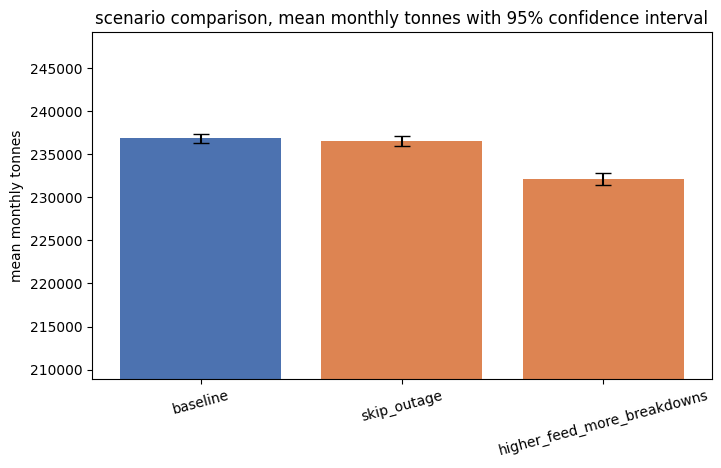

paired comparison against baseline (annual tonnes):
  skip_outage: -3,749 t [-9,995, +2,497], p = 0.2274
  higher_feed_more_breakdowns: -56,053 t [-65,316, -46,790], p = 0.0000


In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
means = table["mean_monthly_tonnes"]
errors = [means - table["ci_low"], table["ci_high"] - means]
ax.bar(table.index, means, yerr=errors, capsize=6, color=["#4C72B0", "#DD8452", "#DD8452"])
ax.set_ylabel("mean monthly tonnes")
ax.set_title("scenario comparison, mean monthly tonnes with 95% confidence interval")
ax.set_ylim(bottom=means.min() * 0.9)
plt.xticks(rotation=15)
plt.show()

print("paired comparison against baseline (annual tonnes):")
for name in table.index:
    if name == "baseline":
        continue
    row = table.loc[name]
    print(f"  {name}: {row['paired_annual_diff_vs_baseline']:+,.0f} t "
          f"[{row['paired_diff_ci_low']:+,.0f}, {row['paired_diff_ci_high']:+,.0f}], "
          f"p = {row['paired_diff_p_value']:.4f}")

## Why the skip outage shows no annual effect

The paired result above says the skip outage is not distinguishable from noise over a full year. That is a real finding, not a bug, and it is worth showing directly rather than just asserting it. The outage clearly hurts the week it happens in, the question is what happens next.

In [5]:
DAY = 24 * 3600
SEED = 100  # same seed used as replication 0 above, for a concrete single run to look at

r_base = run_simulation(scenarios["baseline"], seed=SEED)
r_outage = run_simulation(scenarios["skip_outage"], seed=SEED)


def tonnes_in_window(result, start_day, end_day):
    d = result.cycle_log
    mask = (d["dump_time_s"] >= start_day * DAY) & (d["dump_time_s"] < end_day * DAY)
    return d.loc[mask, "tonnes"].sum()


print("tonnes during the outage week (days 100-107):")
print(f"  baseline:     {tonnes_in_window(r_base, 100, 107):,.0f}")
print(f"  skip_outage:  {tonnes_in_window(r_outage, 100, 107):,.0f}")
print()
print("tonnes during the following two weeks (days 107-121), catching up:")
print(f"  baseline:     {tonnes_in_window(r_base, 107, 121):,.0f}")
print(f"  skip_outage:  {tonnes_in_window(r_outage, 107, 121):,.0f}")

tonnes during the outage week (days 100-107):
  baseline:     55,932
  skip_outage:  46,320

tonnes during the following two weeks (days 107-121), catching up:
  baseline:     107,808
  skip_outage:  103,716


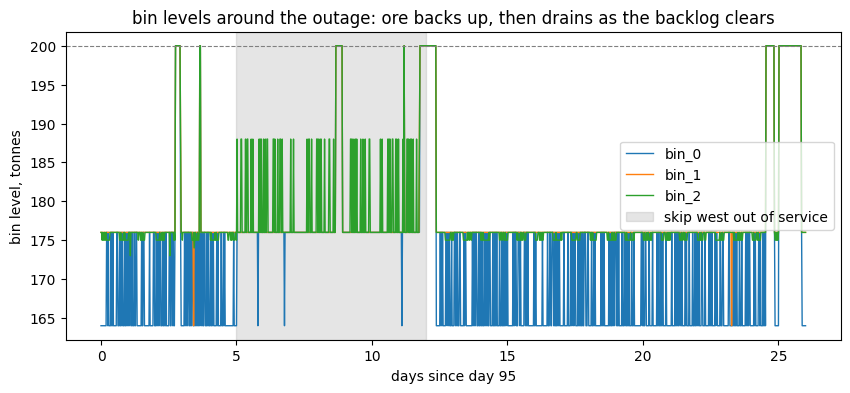

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
window = r_outage.bin_level_log[
    (r_outage.bin_level_log["time_s"] >= 95 * DAY) & (r_outage.bin_level_log["time_s"] <= 121 * DAY)
]
for bin_name, group in window.groupby("bin_name"):
    ax.plot((group["time_s"] - 95 * DAY) / DAY, group["level_tonnes"], label=bin_name, linewidth=1)
ax.axvspan(5, 12, color="grey", alpha=0.2, label="skip west out of service")
ax.axhline(scenarios["baseline"]["bins"]["capacity_tonnes"], color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("days since day 95")
ax.set_ylabel("bin level, tonnes")
ax.set_title("bin levels around the outage: ore backs up, then drains as the backlog clears")
ax.legend()
plt.show()